# 03 Deep local learning and device faults

Every numerical panel below is computed in this notebook from the package's scientific
simulation cores. The default `reduced` profile uses a small live sweep; the exact
publication budgets remain available through `publication`. Authored schematics retain
their original Matplotlib construction. Figures display inline once and saving is opt-in.


## Configuration

The NumPy reference algorithms remain on CPU. Independent conditions and sweep cells are
dispatched to a spawn-safe process pool; BLAS is restricted to one thread per worker.


In [1]:
from pathlib import Path
from contextlib import contextmanager
from IPython.display import display
import hashlib, json, multiprocessing as mp, os, sys

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                 "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(variable, "1")

import numpy as np
import matplotlib.pyplot as plt

RUN_PROFILE = os.getenv("MRL_RUN_PROFILE", "reduced")  # reduced | publication | smoke
DEVICE = os.getenv("MRL_DEVICE", "auto")               # NumPy reference runs on CPU
WORKERS = os.getenv("MRL_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MRL_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MRL_OUTPUT_DIR", "generated_figures"))
OVERWRITE = os.getenv("MRL_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MRL_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MRL_ALLOW_DATA_DOWNLOADS", "0") == "1"
USE_ARCHIVED_RESULTS = os.getenv("MRL_USE_ARCHIVED_RESULTS", os.getenv("MRL_USE_FULL_ARCHIVES", "0")) == "1"

if RUN_PROFILE not in {"reduced", "publication", "smoke"}:
    raise ValueError(f"unknown RUN_PROFILE={RUN_PROFILE!r}")

HERE = Path.cwd()
ROOT = HERE if (HERE / "src" / "mrl_trace").exists() else HERE.parent
sys.path.insert(0, str(ROOT / "src"))
PUB = ROOT / "data" / "publication"
RESULTS = ROOT / "data" / "results"
MANIFEST = json.loads((PUB / "figure_manifest.json").read_text(encoding="utf-8"))
FIGURES = {row["filename"]: row for row in MANIFEST["figures"]}
SELECTED_DEVICE = "cpu"
WORKER_COUNT = (max(1, min(8, (os.cpu_count() or 2) - 1)) if WORKERS == "auto"
                else max(1, int(WORKERS)))

BUDGET = {
    "smoke": dict(distal_gaps=(1, 10), distal_seeds=1, distal_trials=30,
                  local_seeds=1, local_trials=120, dms_seeds=1, dms_trials=120,
                  array_H=(32, 512), array_p=(0.0, 0.5), array_seeds=1, array_trials=80),
    "reduced": dict(distal_gaps=(1, 3, 5, 8, 10, 16, 25), distal_seeds=3,
                    distal_trials=800, local_seeds=4, local_trials=1200,
                    dms_seeds=4, dms_trials=1200, array_H=(8, 32, 128, 512),
                    array_p=(0.0, 0.05, 0.20, 0.50), array_seeds=2, array_trials=800),
    "publication": dict(distal_gaps=(1, 2, 3, 4, 5, 6, 8, 10, 13, 16, 20, 25),
                        distal_seeds=20, distal_trials=2000, local_seeds=20,
                        local_trials=3000, dms_seeds=20, dms_trials=3000,
                        array_H=(8, 32, 128, 512), array_p=(0.0, 0.05, 0.20, 0.50),
                        array_seeds=12, array_trials=2000),
}[RUN_PROFILE]

FIGURE_REPORT = []
print({"profile": RUN_PROFILE, "requested_device": DEVICE, "selected_device": SELECTED_DEVICE,
       "workers": WORKER_COUNT, "saving": SAVE_FIGURES, "archives": USE_ARCHIVED_RESULTS,
       "python": sys.executable, "budget": BUDGET})


{'profile': 'reduced', 'requested_device': 'auto', 'selected_device': 'cpu', 'workers': 8, 'saving': False, 'archives': False, 'python': 'C:\\Users\\User\\git\\mrl-trace\\.venv\\Scripts\\python.exe', 'budget': {'distal_gaps': (1, 3, 5, 8, 10, 16, 25), 'distal_seeds': 3, 'distal_trials': 800, 'local_seeds': 4, 'local_trials': 1200, 'dms_seeds': 4, 'dms_trials': 1200, 'array_H': (8, 32, 128, 512), 'array_p': (0.0, 0.05, 0.2, 0.5), 'array_seeds': 2, 'array_trials': 800}}


## Inline display, optional saving, and provenance

`finish` explicitly displays then closes each figure, preventing the inline backend from
rendering it a second time. Manuscript paths require explicit overwrite permission.


In [2]:
def _hash_arrays(*items):
    h = hashlib.sha256()
    for item in items:
        arr = np.asarray(item)
        h.update(str(arr.shape).encode()); h.update(str(arr.dtype).encode())
        h.update(np.ascontiguousarray(arr).tobytes())
    return h.hexdigest()

def finish(fig, filename, provenance, *, seeds, arrays=()):
    saved = None
    if SAVE_FIGURES:
        out = OUTPUT_DIR.expanduser().resolve()
        if "manuscript" in str(out).lower() and not OVERWRITE:
            raise FileExistsError("writing into a manuscript directory requires OVERWRITE=True")
        out.mkdir(parents=True, exist_ok=True)
        target = out / filename
        if target.exists() and not OVERWRITE:
            raise FileExistsError(target)
        fig.savefig(target, dpi=300, bbox_inches="tight", facecolor="white")
        saved = str(target)
    record = dict(FIGURES.get(filename, {"filename": filename}), runtime_profile=RUN_PROFILE,
                  runtime_device=SELECTED_DEVICE, runtime_workers=WORKER_COUNT,
                  runtime_seeds=seeds, provenance_class=provenance,
                  data_hash=_hash_arrays(*arrays) if arrays else None, saved_path=saved)
    FIGURE_REPORT.append(record)
    display(fig)
    plt.close(fig)
    return None

@contextmanager
def parallel_pool(max_jobs):
    count = min(WORKER_COUNT, max(1, int(max_jobs)))
    if count == 1:
        yield None
        return
    ctx = mp.get_context("spawn")
    with ctx.Pool(count) as pool:
        yield pool

def archived(name):
    path = RESULTS / name
    if not path.exists():
        raise FileNotFoundError(f"requested archive is unavailable: {path}")
    return np.load(path, allow_pickle=True).item()


## Retention as an asset on a deep distal-cue task

The live sweep uses the original deep distal-cue trainer. Seeds are vectorised within a
condition, while gaps, fault levels, and controls run in parallel. Plot construction is
the authored source generator with only file I/O replaced by inline display.


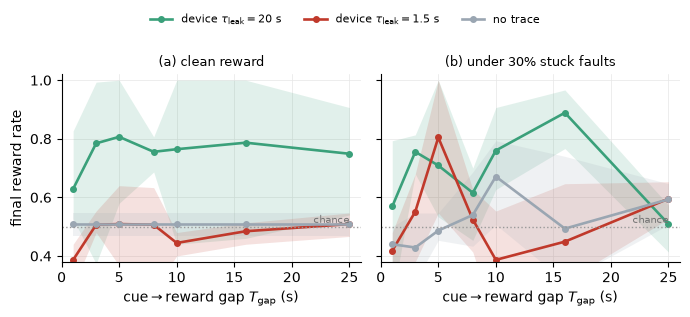

In [3]:
from mrl_trace.distal_cue import run_distal_cue

if USE_ARCHIVED_RESULTS:
    distal = archived("distal_cue_deep.npy")
    distal_provenance = "live-exact-archive"
else:
    njobs = len(BUDGET["distal_gaps"]) * 2 * 3
    with parallel_pool(njobs) as pool:
        distal = run_distal_cue(
            variant="deep", gaps=BUDGET["distal_gaps"], p_grid=(0.0, 0.3),
            seeds=BUDGET["distal_seeds"], trials=BUDGET["distal_trials"],
            window=min(150, BUDGET["distal_trials"]), pool=pool,
            batch_seeds=(RUN_PROFILE != "publication"),
        )
    distal_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

COL = {"long": "#3aa07a", "short": "#c0392b", "no_trace": "#9aa6b2"}
LBL = {"long": r"device $\tau_{\mathrm{leak}}=20$ s",
       "short": r"device $\tau_{\mathrm{leak}}=1.5$ s", "no_trace": "no trace"}

def _panel(ax, d, p, title):
    gaps = d["gaps"]
    for arm in d["arms"]:
        m = np.array([d["summary"][(g, p, arm)][0] for g in gaps])
        lo = np.array([d["summary"][(g, p, arm)][1] for g in gaps])
        hi = np.array([d["summary"][(g, p, arm)][2] for g in gaps])
        ax.plot(gaps, m, "o-", color=COL[arm], lw=1.9, ms=4, label=LBL[arm])
        ax.fill_between(gaps, lo, hi, color=COL[arm], alpha=0.15, lw=0)
    ax.axhline(0.5, color="0.6", ls=":", lw=1.0)
    ax.text(gaps[-1], 0.505, "chance", color="0.45", fontsize=7, ha="right", va="bottom")
    ax.set_xlabel(r"cue$\rightarrow$reward gap $T_{\mathrm{gap}}$ (s)")
    ax.set_ylim(0.38, 1.02); ax.set_xlim(0, gaps[-1] + 1); ax.set_title(title, fontsize=9)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.grid(True, color="0.9", lw=0.5, zorder=0); ax.set_axisbelow(True)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=True)
_panel(axA, distal, 0.0, "(a) clean reward")
_panel(axB, distal, 0.3, "(b) under 30% stuck faults")
axA.set_ylabel("final reward rate")
handles, labels = axA.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout(rect=(0, 0, 1, 0.94))
distal_values = [v for row in distal["summary"].values() for v in row]
finish(fig, "fig_distal_cue_deep.png", distal_provenance,
       seeds=distal["seeds"], arrays=(distal["gaps"], distal_values))


## Deep all-local XOR learning

All six controls use the original package runner and frozen operating point. Conditions
run concurrently; the two-panel plot is retained from the authored experiment listing.


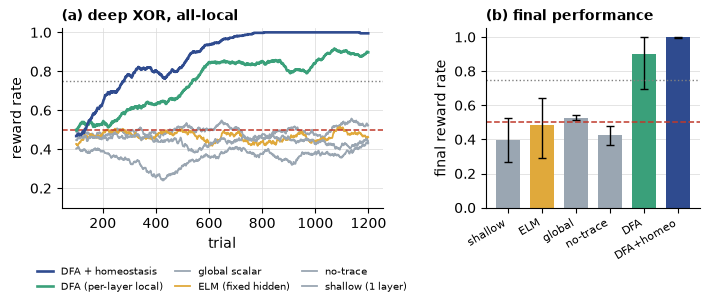

In [4]:
from mrl_trace.deep import run_deep_local

if USE_ARCHIVED_RESULTS:
    deep_local = archived("exp7_deep_local.npy")
    deep_local_provenance = "live-exact-archive"
else:
    with parallel_pool(6) as pool:
        deep_local = run_deep_local(seeds=BUDGET["local_seeds"],
                                    trials=BUDGET["local_trials"], pool=pool)
    deep_local_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

COL = {"shallow": "#9aa6b2", "elm": "#e0a93b", "global": "#9aa6b2",
       "dfa": "#3aa07a", "no_trace": "#9aa6b2", "dfa_homeo": "#2f4b8f"}
LABEL = {"shallow": "shallow (1 layer)", "elm": "ELM (fixed hidden)",
         "global": "global scalar", "dfa": "DFA (per-layer local)",
         "no_trace": "no-trace", "dfa_homeo": "DFA + homeostasis"}
CHANCE, CRIT = deep_local["chance"], deep_local["crit"]
curves, finals, ci = deep_local["curves"], deep_local["finals"], deep_local["ci"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.2, 3.4),
                               gridspec_kw={"width_ratios": [1.5, 1]})
for m in ["dfa_homeo", "dfa", "global", "elm", "no_trace", "shallow"]:
    tt = np.arange(100, 100 + len(curves[m]))
    axA.plot(tt, curves[m], color=COL[m], lw=1.9 if m in ("dfa", "dfa_homeo") else 1.3,
             label=LABEL[m], zorder=4 if m == "dfa_homeo" else (3 if m == "dfa" else 2))
axA.axhline(CHANCE, ls="--", color="#c0392b", lw=1.1)
axA.axhline(CRIT, ls=":", color="0.5", lw=1.0)
axA.set_xlabel("trial"); axA.set_ylabel("reward rate"); axA.set_ylim(0.1, 1.02)
axA.set_title("(a) deep XOR, all-local", loc="left", fontsize=10, fontweight="bold")
axA.legend(frameon=False, fontsize=7, ncol=3, loc="upper center",
           bbox_to_anchor=(0.5, -0.28), columnspacing=1.2, handlelength=1.6)
axA.spines[["top", "right"]].set_visible(False)
axA.grid(True, which="major", color="0.85", lw=0.5, zorder=0); axA.set_axisbelow(True)

order = ["shallow", "elm", "global", "no_trace", "dfa", "dfa_homeo"]
x = np.arange(len(order)); means = [finals[m].mean() for m in order]
los = [finals[m].mean() - ci[m][0] for m in order]
his = [ci[m][1] - finals[m].mean() for m in order]
axB.bar(x, means, color=[COL[m] for m in order], width=0.7,
        yerr=[los, his], capsize=3, error_kw=dict(lw=1.0))
axB.axhline(CHANCE, ls="--", color="#c0392b", lw=1.1)
axB.axhline(CRIT, ls=":", color="0.5", lw=1.0)
axB.set_xticks(x); axB.set_xticklabels(["shallow", "ELM", "global", "no-trace", "DFA", "DFA+homeo"],
                                        rotation=30, ha="right", fontsize=8)
axB.set_ylabel("final reward rate"); axB.set_ylim(0.0, 1.05)
axB.set_title("(b) final performance", loc="left", fontsize=10, fontweight="bold")
axB.spines[["top", "right"]].set_visible(False)
axB.grid(True, axis="y", which="major", color="0.85", lw=0.5, zorder=0); axB.set_axisbelow(True)
fig.tight_layout()
finish(fig, "fig_deep_local.png", deep_local_provenance, seeds=deep_local["seeds"],
       arrays=tuple(finals[m] for m in order))


## Deep temporal–spatial credit

This convergence test combines a temporal distractor with two-layer local learning.
The simulation and plotting code follow the authored experiment and generator.


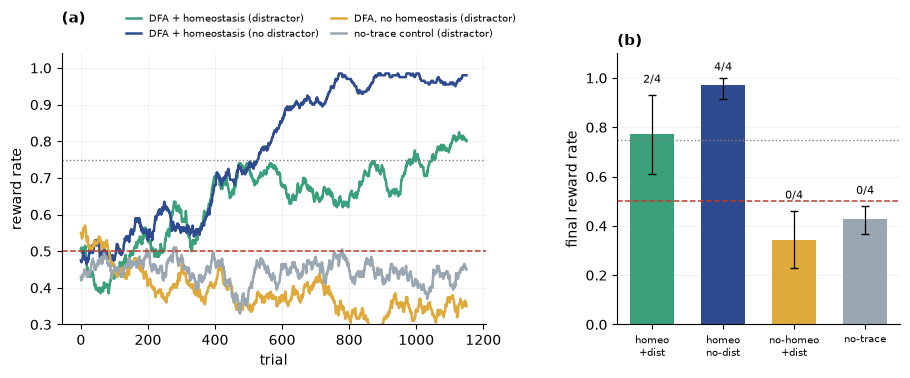

In [5]:
from mrl_trace.deep import run_deep_dms

if USE_ARCHIVED_RESULTS:
    deep_dms = archived("exp13_deep_dms.npy")
    deep_dms_provenance = "live-exact-archive"
else:
    with parallel_pool(4) as pool:
        deep_dms = run_deep_dms(seeds=BUDGET["dms_seeds"],
                                trials=BUDGET["dms_trials"], pool=pool)
    deep_dms_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

LABELS = {"dfa_homeo_dist": "DFA + homeostasis (distractor)",
          "dfa_homeo_nodist": "DFA + homeostasis (no distractor)",
          "dfa_dist": "DFA, no homeostasis (distractor)",
          "no_trace_dist": "no-trace control (distractor)"}
COL = {"dfa_homeo_dist": "#3aa07a", "dfa_homeo_nodist": "#2f4b8f",
       "dfa_dist": "#e0a93b", "no_trace_dist": "#9aa6b2"}
ORDER = ["dfa_homeo_dist", "dfa_homeo_nodist", "dfa_dist", "no_trace_dist"]
curves, finals, ci = deep_dms["curves"], deep_dms["finals"], deep_dms["ci"]
solved, seeds = deep_dms["seeds_solved"], deep_dms["seeds"]
chance, crit = deep_dms["chance"], deep_dms["crit"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.2, 3.9),
                               gridspec_kw={"width_ratios": [1.5, 1.0]})
for k in ORDER:
    c = np.asarray(curves[k]); w = min(50, len(c))
    rc = np.convolve(c, np.ones(w) / w, mode="valid")
    axA.plot(np.arange(len(rc)), rc, color=COL[k], lw=1.8, label=LABELS[k])
axA.axhline(chance, ls="--", color="#c0392b", lw=1.1)
axA.axhline(crit, ls=":", color="0.5", lw=1.0)
axA.set_xlabel("trial"); axA.set_ylabel("reward rate"); axA.set_ylim(0.3, 1.04)
axA.text(0.0, 1.10, "(a)", transform=axA.transAxes, fontsize=11, fontweight="bold",
         va="bottom", ha="left")
axA.legend(fontsize=7.0, loc="lower left", bbox_to_anchor=(0.13, 1.02),
           ncol=2, frameon=False, columnspacing=1.2, handlelength=1.6)
axA.spines[["top", "right"]].set_visible(False)
axA.grid(True, color="0.92", lw=0.5); axA.set_axisbelow(True)

x = np.arange(len(ORDER)); means = [np.asarray(finals[k]).mean() for k in ORDER]
los = [means[i] - ci[k][0] for i, k in enumerate(ORDER)]
his = [ci[k][1] - means[i] for i, k in enumerate(ORDER)]
axB.bar(x, means, 0.62, color=[COL[k] for k in ORDER],
        yerr=[los, his], capsize=3, error_kw=dict(lw=0.9))
for i, k in enumerate(ORDER):
    axB.text(i, min(means[i] + his[i] + 0.04, 1.02), f"{solved[k]}/{seeds}",
             ha="center", va="bottom", fontsize=8)
axB.axhline(chance, ls="--", color="#c0392b", lw=1.1)
axB.axhline(crit, ls=":", color="0.5", lw=1.0)
axB.set_xticks(x); axB.set_xticklabels(["homeo\n+dist", "homeo\nno-dist", "no-homeo\n+dist", "no-trace"], fontsize=7.5)
axB.set_ylabel("final reward rate"); axB.set_ylim(0, 1.1)
axB.set_title("(b)", loc="left", fontsize=11, fontweight="bold")
axB.spines[["top", "right"]].set_visible(False)
axB.grid(True, axis="y", color="0.92", lw=0.5); axB.set_axisbelow(True)
fig.tight_layout()
finish(fig, "fig_deep_dms.png", deep_dms_provenance, seeds=seeds,
       arrays=tuple(finals[k] for k in ORDER))


## Shallow delayed-match control

The same temporal primitive is isolated in a one-layer DMS task. Conditions run in
parallel; learning curves and confidence bands use the original generator.


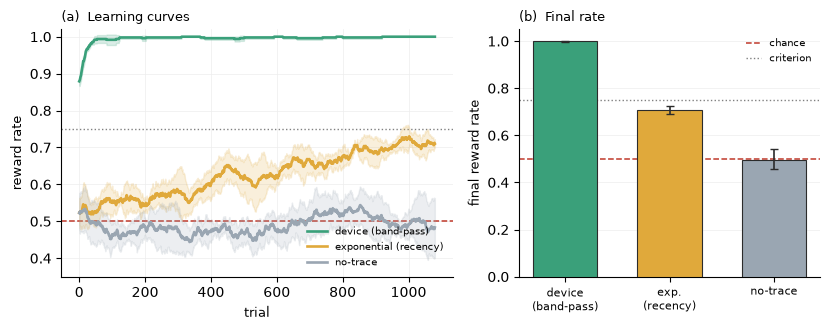

In [6]:
from mrl_trace.deep import run_dms_all

if USE_ARCHIVED_RESULTS:
    shallow_dms = archived("exp12_dms.npy")
    shallow_dms_provenance = "live-exact-archive"
else:
    with parallel_pool(3) as pool:
        shallow_dms = run_dms_all(seeds=BUDGET["dms_seeds"],
                                  trials=BUDGET["dms_trials"], pool=pool)
    shallow_dms_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

INK = "#2b2b2b"; DEVICE_COL = "#3aa07a"; RECENCY = "#e0a93b"; NTC = "#9aa6b2"; CR = "#c0392b"
order = ["device", "abstract", "no_trace"]
disp = {"device": "device (band-pass)", "abstract": "exponential (recency)", "no_trace": "no-trace"}
cols = {"device": DEVICE_COL, "abstract": RECENCY, "no_trace": NTC}
chance, crit = shallow_dms["chance"], shallow_dms["crit"]

def _running(x, win=120):
    if len(x) < win: return x
    c = np.cumsum(np.insert(x, 0, 0.0)); return (c[win:] - c[:-win]) / win

fig, (axA, axB) = plt.subplots(1, 2, figsize=(8.4, 3.4),
                               gridspec_kw={"width_ratios": [1.3, 1.0]})
raw = shallow_dms.get("raw")
for k in order:
    seeds_curves = np.apply_along_axis(_running, 1, np.asarray(raw[k]))
    m = seeds_curves.mean(0); sd = seeds_curves.std(0) / np.sqrt(seeds_curves.shape[0]); t = np.arange(len(m))
    axA.fill_between(t, m - 1.96 * sd, m + 1.96 * sd, color=cols[k], alpha=0.18, zorder=2)
    axA.plot(t, m, color=cols[k], lw=1.9, label=disp[k], zorder=3)
axA.axhline(chance, color=CR, ls="--", lw=1.1, zorder=1)
axA.axhline(crit, color="0.5", ls=":", lw=1.0, zorder=1)
axA.set_xlabel("trial", fontsize=9.5); axA.set_ylabel("reward rate", fontsize=9.5); axA.set_ylim(0.35, 1.02)
axA.set_title("(a)  Learning curves", fontsize=9.5, loc="left")
axA.legend(fontsize=7.2, loc="lower right", frameon=False)
for s in ("top", "right"): axA.spines[s].set_visible(False)
axA.grid(True, color="0.93", lw=0.5); axA.set_axisbelow(True)

x = np.arange(len(order)); means = [float(np.mean(shallow_dms["finals"][k])) for k in order]
lo = [means[i] - shallow_dms["ci"][k][0] for i, k in enumerate(order)]
hi = [shallow_dms["ci"][k][1] - means[i] for i, k in enumerate(order)]
axB.bar(x, means, color=[cols[k] for k in order], edgecolor=INK, lw=0.8, width=0.62, zorder=3)
axB.errorbar(x, means, yerr=[lo, hi], fmt="none", ecolor=INK, elinewidth=1.2, capsize=3, zorder=4)
axB.axhline(chance, color=CR, ls="--", lw=1.1, zorder=1, label="chance")
axB.axhline(crit, color="0.5", ls=":", lw=1.0, zorder=1, label="criterion")
axB.legend(fontsize=7.0, loc="upper right", frameon=False, handlelength=1.6)
axB.set_xticks(x); axB.set_xticklabels(["device\n(band-pass)", "exp.\n(recency)", "no-trace"], fontsize=7.8)
axB.set_ylim(0, 1.05); axB.set_ylabel("final reward rate", fontsize=9.5)
axB.set_title("(b)  Final rate", fontsize=9.5, loc="left")
for s in ("top", "right"): axB.spines[s].set_visible(False)
axB.grid(True, axis="y", color="0.93", lw=0.5); axB.set_axisbelow(True)
fig.tight_layout()
finish(fig, "fig_shallow_dms.png", shallow_dms_provenance, seeds=shallow_dms["seeds"],
       arrays=tuple(shallow_dms["finals"][k] for k in order))


## Homeostatic stabilisation principle

Authored first-principles schematic, reproduced from its authored source generator. It is
deliberately a drawn control-theoretic illustration, not simulated evidence.


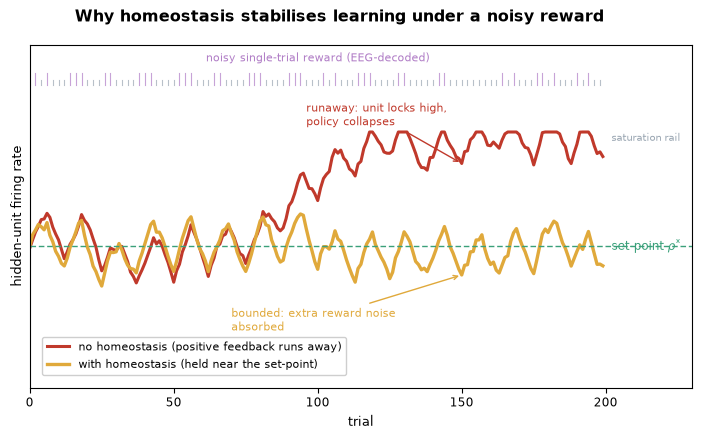

In [7]:
import os
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch, Patch

INK    = "#222222"
POS    = "#c0392b"     # positive feedback / runaway (red)
HOMEO  = "#e0a93b"     # homeostasis (orange)
EEG    = "#b07cc6"     # EEG / noisy reward (indigo)
NET    = "#2f4b8f"
GREEN  = "#3aa07a"
NEU    = "#9aa6b2"
SET    = "#3aa07a"     # set-point

def feedback_ring(ax, cx, cy, r, color, sign, ccw=True):
    """A circular feedback arrow with a +/- sign in the middle."""
    th0, th1 = (200, -110) if ccw else (-20, 250)
    arc = np.linspace(np.deg2rad(th0), np.deg2rad(th1), 100)
    ax.plot(cx+r*np.cos(arc), cy+r*np.sin(arc), color=color, lw=2.6, zorder=4)
    # arrowhead at the end
    a = arc[-1]; da = (arc[-1]-arc[-2])
    ax.add_patch(FancyArrowPatch((cx+r*np.cos(a-da), cy+r*np.sin(a-da)),
                 (cx+r*np.cos(a), cy+r*np.sin(a)), arrowstyle="-|>",
                 mutation_scale=16, color=color, lw=2.6, zorder=5))
    ax.text(cx, cy, sign, ha="center", va="center", fontsize=20, fontweight="bold",
            color=color, zorder=6)

def panel_a(ax):
    ax.text(-0.04, 1.08, "(a)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("Associative plasticity is positive feedback", fontsize=9.4, fontweight="bold", pad=6)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
    # the loop: fires more -> weights grow -> fires more
    feedback_ring(ax, 5.0, 6.3, 1.7, POS, "$+$", ccw=True)
    ax.text(5.0, 8.5, "neuron fires more", ha="center", fontsize=8.0, color=POS)
    ax.text(8.0, 6.3, "its weights\ngrow", ha="center", fontsize=8.0, color=POS)
    ax.text(2.0, 6.3, "drive\nrises", ha="center", fontsize=8.0, color=POS)
    # runaway trace
    t = np.linspace(0, 1, 100)
    run = 1/(1+np.exp(-(t-0.45)*12))           # logistic blow-up to the rail
    ax.plot(1.2+t*7.6, 0.8+run*2.6, color=POS, lw=2.2)
    ax.axhline(0.8+2.6, xmin=0.12, xmax=0.88, color=NEU, lw=0.8, ls=(0,(3,2)))
    ax.text(8.9, 0.8+2.6, "rail", fontsize=6.8, color=NEU, va="center")
    ax.text(5.0, 0.35, "left alone: a hidden unit locks high $\\to$ policy collapses",
            ha="center", fontsize=7.4, color=POS, style="italic")

def panel_b(ax):
    ax.text(-0.04, 1.08, "(b)", transform=ax.transAxes, fontsize=13, fontweight="bold")
    ax.set_title("Homeostasis is the negative-feedback counterweight", fontsize=9.4, fontweight="bold", pad=6)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
    feedback_ring(ax, 5.0, 6.3, 1.7, HOMEO, "$-$", ccw=False)
    ax.text(5.0, 8.5, "rate above $\\rho^{\\!*}$", ha="center", fontsize=8.0, color=HOMEO)
    ax.text(8.1, 6.3, "weights\npulled down", ha="center", fontsize=8.0, color=HOMEO)
    ax.text(1.9, 6.3, "rate\nreturns", ha="center", fontsize=8.0, color=HOMEO)
    # rate settling to set-point
    t = np.linspace(0, 1, 200)
    settle = 0.5 + 0.5*np.exp(-t*5)*np.cos(t*14)   # damped to set-point
    ax.plot(1.2+t*7.6, 0.8+settle*2.6, color=HOMEO, lw=2.2)
    ax.axhline(0.8+0.5*2.6, xmin=0.12, xmax=0.88, color=SET, lw=1.0, ls=(0,(4,2)))
    ax.text(8.9, 0.8+0.5*2.6, r"$\rho^{\!*}$", fontsize=8.5, color=SET, va="center")
    ax.text(5.0, 0.35, "each neuron holds its own rate near a shared set-point",
            ha="center", fontsize=7.4, color=HOMEO, style="italic")

def panel_c(ax):
    rng = np.random.RandomState(3)
    n = 200; trial = np.arange(n)
    # noisy reward strip at the top
    rew = 0.5 + 0.5*np.sign(np.sin(trial*0.5)) * (rng.rand(n) < 0.85)  # noisy +/- reward
    ax.plot(trial, 9.3 + 0.001*trial, color="none")
    for i in range(0, n, 2):
        c = EEG if rew[i] > 0.5 else NEU
        ax.plot([trial[i], trial[i]], [9.0, 9.0+0.35*(0.4+0.6*(rew[i]>0.5))], color=c, lw=0.8, alpha=0.7)
    ax.text(n/2, 9.7, "noisy single-trial reward (EEG-decoded)", ha="center", fontsize=8.0, color=EEG)

    # without homeostasis: firing rate diverges to a rail (positive feedback unchecked)
    rho = 0.5; x = rho; traj_no = []
    for i in range(n):
        x += 0.018*(rew[i]-0.5)*4 + 0.03*(x-rho) + 0.01*rng.randn()  # pos feedback (x-rho) destabilises
        x = np.clip(x, 0, 1); traj_no.append(x)
    ax.plot(trial, np.array(traj_no)*6.8+0.8, color=POS, lw=2.2,
            label="no homeostasis (positive feedback runs away)")

    # with homeostasis: bounded near set-point (negative-feedback counterweight)
    x = rho; traj_h = []
    for i in range(n):
        x += 0.018*(rew[i]-0.5)*4 + 0.03*(x-rho) - 0.16*(x-rho) + 0.01*rng.randn()  # neg feedback dominates
        x = np.clip(x, 0, 1); traj_h.append(x)
    ax.plot(trial, np.array(traj_h)*6.8+0.8, color=HOMEO, lw=2.4,
            label="with homeostasis (held near the set-point)")

    ax.axhline(rho*6.8+0.8, color=SET, lw=1.0, ls=(0,(4,2)))
    ax.text(n+2, rho*6.8+0.8, r"set-point $\rho^{\!*}$", fontsize=8.5, color=SET, va="center")
    ax.text(n+2, 1.0*6.8+0.8-0.18, "saturation rail", fontsize=7.4, color=NEU, va="center")
    # name the two control regimes directly on the curves
    ax.annotate("runaway: unit locks high,\npolicy collapses", xy=(150, traj_no[150]*6.8+0.8),
                xytext=(96, 8.1), fontsize=7.6, color=POS, va="center",
                arrowprops=dict(arrowstyle="->", color=POS, lw=1.0))
    ax.annotate("bounded: extra reward noise\nabsorbed", xy=(150, traj_h[150]*6.8+0.8),
                xytext=(70, 2.0), fontsize=7.6, color=HOMEO, va="center",
                arrowprops=dict(arrowstyle="->", color=HOMEO, lw=1.0))

    ax.set_xlim(0, n+30); ax.set_ylim(0, 10.2)
    ax.set_xlabel("trial", fontsize=9.5)
    ax.set_ylabel("hidden-unit firing rate", fontsize=9.5)
    ax.set_yticks([]); ax.tick_params(labelsize=8.5)
    ax.legend(loc="lower left", fontsize=8.2, framealpha=0.95, bbox_to_anchor=(0.01, 0.02))

fig, ax = plt.subplots(figsize=(7.2, 4.4))
panel_c(ax)
fig.suptitle("Why homeostasis stabilises learning under a noisy reward",
             fontsize=11.5, fontweight="bold", y=0.98)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.12)

finish(fig, 'fig_homeostasis_stab.png', 'immutable-authored', seeds=None)


## Deep all-local crossbar

Authored two-panel hardware schematic, using the authored patch-and-line construction.


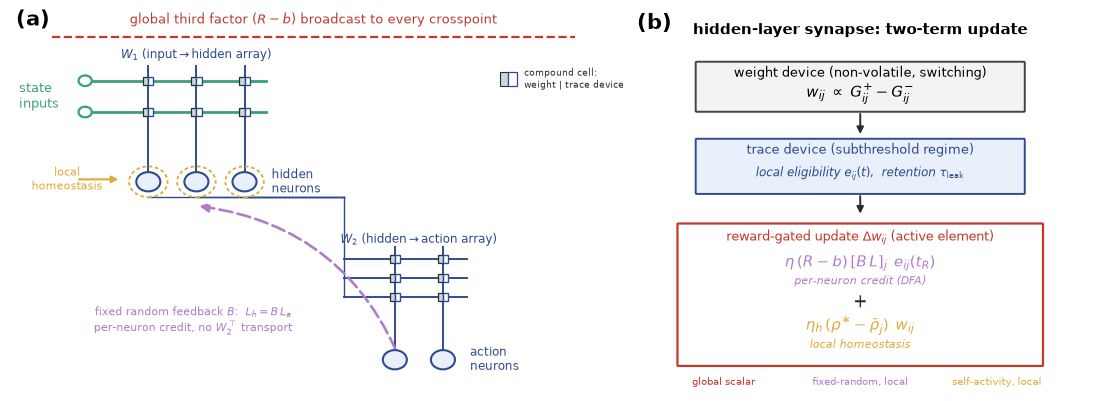

In [8]:
import os
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch, Rectangle

# palette matched to crossbar.png
GREEN = "#3aa07a"      # state-input lines
BLUE = "#2f4b8f"       # device synapses / LIF / forward path
LBLUE = "#eaf0fb"      # device-gate fill
RED = "#c0392b"        # global reward broadcast
PURPLE = "#b07cc6"     # fixed-random feedback (DFA), distinct from forward blue
ORANGE = "#e0a93b"     # homeostasis (local activity regulation)
GREY = "#9aa6b2"
INK = "#2b2b2b"

def _box(ax, xy, w, h, fc, ec, **kw):
    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.012,rounding_size=0.02",
                                fc=fc, ec=ec, lw=kw.pop("lw", 1.4), zorder=kw.pop("z", 3), **kw))

def _compound_node(ax, cx, cy, s=0.085):
    """A crossbar synapse drawn as a compact two-tone split square: left half = the
    non-volatile WEIGHT device, right half = the subthreshold TRACE device. Signals the
    two-device compound cell at array scale without three sub-glyphs per tiny node."""
    ax.add_patch(Rectangle((cx - s, cy - s), s, 2 * s, fc="#cbd6e0", ec=INK, lw=0.9, zorder=4))
    ax.add_patch(Rectangle((cx, cy - s), s, 2 * s, fc="white", ec=BLUE, lw=1.0, zorder=4))

def panel_a(ax, tag=True):
    ax.set_xlim(0, 10); ax.set_ylim(-0.3, 7.6); ax.axis("off")
    if tag:
        ax.text(0.1, 7.3, "(a)", fontsize=15, fontweight="bold")

    # ---- global reward broadcast (top, red dashed) -------------------------------
    ax.plot([0.7, 9.4], [7.05, 7.05], color=RED, ls="--", lw=1.6, zorder=2)
    ax.text(5.05, 7.32, r"global third factor $(R-b)$ broadcast to every crosspoint",
            color=RED, fontsize=9.5, ha="center")

    # ---- layer 1 array: inputs (rows) x hidden (cols) ----------------------------
    in_y = [6.15, 5.5]                      # F input lines (2 shown)
    h_x = [2.3, 3.1, 3.9]                   # H hidden columns (3 shown)
    h_lif_y = 4.05
    ax.text(0.15, 5.82, "state\ninputs", color=GREEN, fontsize=9, va="center")
    for x in h_x:                           # hidden bitlines drop to the LIF row
        ax.plot([x, x], [6.45, h_lif_y + 0.2], color=BLUE, lw=1.4, zorder=1)
    for y in in_y:
        ax.add_patch(Circle((1.25, y), 0.11, fc="white", ec=GREEN, lw=1.6, zorder=4))
        ax.plot([1.36, 4.25], [y, y], color=GREEN, lw=2.0, zorder=2)
    for y in in_y:                          # W1 synapses: compound (weight|trace) cells
        for x in h_x:
            _compound_node(ax, x, y, s=0.085)
    ax.text(3.1, 6.62, r"$W_1$ (input$\rightarrow$hidden array)",
            color=BLUE, fontsize=8.5, ha="center")

    # ---- hidden LIF layer (with homeostasis rings) -------------------------------
    for x in h_x:
        ax.add_patch(Circle((x, h_lif_y), 0.32, fc="none", ec=ORANGE, lw=1.3,
                            ls=(0, (2, 1.5)), zorder=4))      # homeostasis ring
        ax.add_patch(Circle((x, h_lif_y), 0.20, fc="#eaf0fb", ec=BLUE, lw=1.5, zorder=5))
        ax.text(x, h_lif_y, "LIF", color=BLUE, fontsize=6.5, ha="center", va="center")
    ax.text(4.35, h_lif_y, "hidden\nneurons", color=BLUE, fontsize=8.5, va="center")
    ax.annotate("", xy=(1.85, h_lif_y + 0.05), xytext=(1.1, h_lif_y + 0.05),
                arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=1.5))
    ax.text(0.95, h_lif_y + 0.05, "local\nhomeostasis", color=ORANGE, fontsize=8.0,
            ha="center", va="center")

    # ---- layer 2 array: hidden (rows) x action (cols) ----------------------------
    a_x = [6.4, 7.2]                        # A action columns (2 shown)
    row2_y = [2.45, 2.05, 1.65]             # H hidden rows feeding layer 2
    bus_x = 5.55
    for i, x in enumerate(h_x):             # hidden activity routed to layer-2 rows
        ax.plot([x, bus_x], [h_lif_y - 0.32, h_lif_y - 0.32], color=BLUE, lw=1.0, zorder=1)
    ax.plot([bus_x, bus_x], [h_lif_y - 0.32, row2_y[-1]], color=BLUE, lw=1.0, zorder=1)
    for y in row2_y:
        ax.plot([bus_x, 7.6], [y, y], color=BLUE, lw=1.4, zorder=1)
    for x in a_x:
        ax.plot([x, x], [2.7, 0.55], color=BLUE, lw=1.4, zorder=1)
        for y in row2_y:
            _compound_node(ax, x, y, s=0.080)
    ax.text(6.8, 2.78, r"$W_2$ (hidden$\rightarrow$action array)",
            color=BLUE, fontsize=8.5, ha="center")
    # legend: each array node is a compound cell (weight half + trace half)
    ax.add_patch(Rectangle((8.15, 6.05), 0.14, 0.28, fc="#cbd6e0", ec=INK, lw=0.8, zorder=5))
    ax.add_patch(Rectangle((8.29, 6.05), 0.14, 0.28, fc="white", ec=BLUE, lw=0.9, zorder=5))
    ax.text(8.55, 6.19, "compound cell:\nweight | trace device", color=INK, fontsize=6.6, va="center")

    # ---- action LIF + WTA --------------------------------------------------------
    for x in a_x:
        ax.add_patch(Circle((x, 0.35), 0.20, fc="#eaf0fb", ec=BLUE, lw=1.5, zorder=5))
        ax.text(x, 0.35, "LIF", color=BLUE, fontsize=6.5, ha="center", va="center")
    ax.text(7.65, 0.35, "action\nneurons", color=BLUE, fontsize=8.5, va="center")

    # ---- DFA fixed-random feedback array (purple) --------------------------------
    # output error projected to the hidden layer through a FIXED RANDOM matrix (no W2^T)
    fb = FancyArrowPatch((6.55, 0.15), (3.1, 3.55), connectionstyle="arc3,rad=0.30",
                         arrowstyle="-|>", mutation_scale=13, color=PURPLE, lw=1.9,
                         ls=(0, (5, 2)), zorder=2)
    ax.add_patch(fb)
    ax.text(3.05, 1.15, r"fixed random feedback $B$:  $L_h = B\,L_a$" "\n"
            r"per-neuron credit, no $W_2^{\top}$ transport",
            color=PURPLE, fontsize=8.0, ha="center", va="center")

    # (array-dimension annotation removed -- the caption describes the two
    #  stacked W_1, W_2 arrays flanking the hidden layer)

def panel_b(ax, tag=True):
    ax.set_xlim(0, 10); ax.set_ylim(0, 7.4); ax.axis("off")
    if tag:
        ax.text(0.1, 7.05, "(b)", fontsize=15, fontweight="bold")
    ax.text(5.0, 6.95, "hidden-layer synapse: two-term update", fontsize=10.5, fontweight="bold", ha="center")

    # weight device (non-volatile)
    _box(ax, (1.4, 5.45), 7.2, 0.95, "#f1f3f5", "#444")
    ax.text(5.0, 6.12, r"weight device (non-volatile, switching)", fontsize=9.0, ha="center")
    ax.text(5.0, 5.72, r"$w_{ij}\;\propto\;G^{+}_{ij}-G^{-}_{ij}$", fontsize=11, ha="center")
    # arrows flow top->bottom (weight -> gate -> update): arrowhead (xy) at the LOWER box,
    # tail (xytext) at the upper box, so the head points DOWN into the next stage.
    ax.annotate("", xy=(5.0, 4.95), xytext=(5.0, 5.45),
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.4))

    # trace device (subthreshold) / eligibility
    _box(ax, (1.4, 3.85), 7.2, 1.05, LBLUE, BLUE)
    ax.text(5.0, 4.62, "trace device (subthreshold regime)", color=BLUE, fontsize=9.0, ha="center")
    ax.text(5.0, 4.18, r"local eligibility $e_{ij}(t)$,  retention $\tau_{\mathrm{leak}}$",
            color=BLUE, fontsize=8.5, ha="center", style="italic")
    # tiny eligibility glyph
    tt = np.linspace(0, 1, 60)
    gl = (1 - np.exp(-(tt / 0.18) ** 2)) * np.exp(-tt / 0.5)
    ax.plot(1.7 + tt * 0.9, 4.0 + gl * 0.55, color=BLUE, lw=1.3)
    ax.annotate("", xy=(5.0, 3.4), xytext=(5.0, 3.85),
                arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.4))

    # local update box: two contributions; reward-gated multiply-write by an active
    # element (per-cell selector/transistor or shared peripheral CMOS), not the memristors
    _box(ax, (1.0, 0.5), 8.0, 2.75, "white", RED, lw=1.6)
    ax.text(5.0, 2.92, r"reward-gated update $\Delta w_{ij}$ (active element)", color=RED, fontsize=9.0, ha="center")
    # term 1: feedback-aligned credit
    ax.text(5.0, 2.42, r"$\eta\,(R-b)\,[B\,L]_{j}\;\,e_{ij}(t_R)$",
            fontsize=11, ha="center", color=PURPLE)
    ax.text(5.0, 2.08, "per-neuron credit (DFA)", fontsize=7.6, ha="center",
            color=PURPLE, style="italic")
    # plus
    ax.text(5.0, 1.62, r"$+$", fontsize=12, ha="center", color=INK)
    # term 2: homeostatic regulation
    ax.text(5.0, 1.18, r"$\eta_h\,(\rho^{\ast}-\bar\rho_j)\;\,w_{ij}$",
            fontsize=11, ha="center", color=ORANGE)
    ax.text(5.0, 0.84, "local homeostasis", fontsize=7.6, ha="center",
            color=ORANGE, style="italic")
    # (grey "rho_j: neuron's own activity / rho*: shared target" gloss removed
    #  -- both symbols are defined in the surrounding text, Eq. 7.14 paragraph)

    # local/global annotations
    ax.text(2.0, 0.12, "global scalar", color=RED, fontsize=7.4, ha="center")
    ax.text(5.0, 0.12, "fixed-random, local", color=PURPLE, fontsize=7.4, ha="center")
    ax.text(8.0, 0.12, "self-activity, local", color=ORANGE, fontsize=7.4, ha="center")

# combined two-panel version (kept for reference)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.0, 4.0),
                               gridspec_kw={"width_ratios": [1.32, 1.0]})
panel_a(axA)
panel_b(axB)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.04, wspace=0.04)

finish(fig, 'fig_deep_crossbar.png', 'immutable-authored', seeds=None)


## Array-scale fault tolerance

Two live sweeps retain the authored heatmap style but test distinct priors: the realistic
asymmetric programmed-conductance prior used by the fault claim, and the harsher full-PF
context run. Every hidden-width × fault × control cell is dispatched independently.


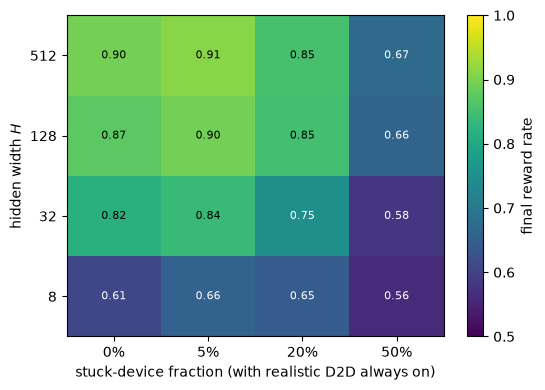

In [9]:
from mrl_trace.deep import run_array_scale

if USE_ARCHIVED_RESULTS:
    array_faults = archived("exp14_array_scale_sweep.npy")
    array_faults_provenance = "live-exact-archive"
else:
    cells_n = len(BUDGET["array_H"]) * len(BUDGET["array_p"]) * BUDGET["array_seeds"]
    with parallel_pool(cells_n) as pool:
        array_faults = run_array_scale(
            H_grid=BUDGET["array_H"], p_grid=BUDGET["array_p"],
            seeds=BUDGET["array_seeds"], trials=BUDGET["array_trials"],
            sigma_g=0.5, sigma_g_on=0.05, pf_on=False, pool=pool,
            include_control=False,
        )
    array_faults_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

H, p, grid = array_faults["H"], array_faults["p"], np.asarray(array_faults["grid"])
fig, ax = plt.subplots(figsize=(5.6, 4.0))
im = ax.imshow(grid[..., 0], origin="lower", cmap="viridis", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(p))); ax.set_xticklabels([f"{q:.0%}" for q in p])
ax.set_yticks(range(len(H))); ax.set_yticklabels(H)
ax.set_xlabel("stuck-device fraction (with realistic D2D always on)"); ax.set_ylabel("hidden width $H$")
for i in range(len(H)):
    for j in range(len(p)):
        ax.text(j, i, f"{grid[i, j, 0]:.2f}", ha="center", va="center",
                color="w" if grid[i, j, 0] < 0.8 else "k", fontsize=8)
fig.colorbar(im, ax=ax, label="final reward rate")
fig.tight_layout()
finish(fig, "fig_array_faults.png", array_faults_provenance, seeds=array_faults["seeds"],
       arrays=(grid, array_faults["ctrl"]))


## Full-PF array-scale context

This is not a duplicate of the preceding claim panel: it keeps Poole–Frenkel read-path
nonlinearity enabled and therefore serves as the deliberately harsher context sweep.


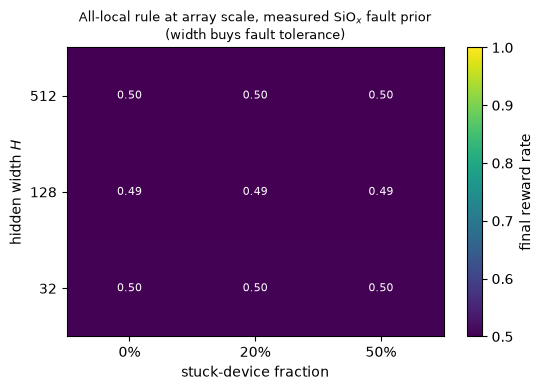

In [10]:
if USE_ARCHIVED_RESULTS:
    array_scale = archived("exp14_array_scale.npy")
    array_scale_provenance = "live-exact-archive"
else:
    scale_H = (32, 128, 512) if RUN_PROFILE != "smoke" else BUDGET["array_H"]
    scale_p = (0.0, 0.20, 0.50) if RUN_PROFILE != "smoke" else BUDGET["array_p"]
    cells_n = len(scale_H) * len(scale_p) * BUDGET["array_seeds"]
    with parallel_pool(cells_n) as pool:
        array_scale = run_array_scale(H_grid=scale_H, p_grid=scale_p,
                                      seeds=BUDGET["array_seeds"],
                                      trials=BUDGET["array_trials"],
                                      sigma_g=0.5, pf_on=True, pool=pool,
                                      include_control=False)
    array_scale_provenance = "live-reduced" if RUN_PROFILE != "publication" else "live-exact"

H, p, grid = array_scale["H"], array_scale["p"], np.asarray(array_scale["grid"])
fig, ax = plt.subplots(figsize=(5.6, 4.0))
im = ax.imshow(grid[..., 0], origin="lower", cmap="viridis", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(p))); ax.set_xticklabels([f"{q:.0%}" for q in p])
ax.set_yticks(range(len(H))); ax.set_yticklabels(H)
ax.set_xlabel("stuck-device fraction"); ax.set_ylabel("hidden width $H$")
for i in range(len(H)):
    for j in range(len(p)):
        ax.text(j, i, f"{grid[i, j, 0]:.2f}", ha="center", va="center",
                color="w" if grid[i, j, 0] < 0.8 else "k", fontsize=8)
fig.colorbar(im, ax=ax, label="final reward rate")
ax.set_title("All-local rule at array scale, measured SiO$_x$ fault prior\n(width buys fault tolerance)", fontsize=9.5)
fig.tight_layout()
finish(fig, "fig_array_scale.png", array_scale_provenance, seeds=array_scale["seeds"],
       arrays=(grid, array_scale["ctrl"]))


## Notebook report

In [11]:
expected = {'fig_distal_cue_deep.png', 'fig_deep_local.png', 'fig_deep_dms.png',
            'fig_shallow_dms.png', 'fig_homeostasis_stab.png', 'fig_deep_crossbar.png',
            'fig_array_faults.png', 'fig_array_scale.png'}
actual = [row['filename'] for row in FIGURE_REPORT]
assert len(actual) == len(expected) == 8
assert set(actual) == expected and len(set(actual)) == len(actual)
assert not SAVE_FIGURES or all(row['saved_path'] for row in FIGURE_REPORT)
FIGURE_REPORT


[{'filename': 'fig_distal_cue_deep.png',
  'tier': 'main',
  'notebook': '03_deep_local_and_faults.ipynb',
  'profile': 'publication',
  'device': 'cpu',
  'seeds': 20,
  'data_hash': 'c2e1f803b1b06ac4b211210cd2a4fb651d833f679be63ae059d14342e5aed598',
  'reference_hash': '9dd4eb94d2edca5aec7b084dd033cfa2bd8a1cf165fff6347f4a9e251745869f',
  'provenance_class': 'live-reduced',
  'claim_status': 'aggregate-reproduction',
  'runtime_profile': 'reduced',
  'runtime_device': 'cpu',
  'runtime_workers': 8,
  'runtime_seeds': 3,
  'saved_path': None},
 {'filename': 'fig_deep_local.png',
  'tier': 'main',
  'notebook': '03_deep_local_and_faults.ipynb',
  'profile': 'publication',
  'device': 'cpu',
  'seeds': 20,
  'data_hash': '10d411bbc23063a79de60531f5005c3ea803227e9bb24bd30b12fc7cd71fffe3',
  'reference_hash': 'b20731fd6adbbc499451b1f87ac39e5fd2a14c05fc450023ee81d2c4615c5b28',
  'provenance_class': 'live-reduced',
  'claim_status': 'aggregate-reproduction',
  'runtime_profile': 'reduced',
 